# **CSI 4142: Assignment 4** </br> Unsupervised Learning

## **Group members**
**Group 8**

| Name | Student ID |
|------|------------|
| Zixin Fan | 300296371 |
| Solin Maaroof | 300250903 | 

## **Task distribution**
- Zixin Fan: Clustering (study 2) and Collaborative Filtering (study 4).

- Solin Maaroof: Similarity Measures (study 1) and Content-Based Recommendation System (study 3).

## **Libraries and Packages**

In [6]:
import pandas as pd # For data manipulation and analysis using DataFrames
import numpy as np # For numberical computing and array/ matrix operations
import seaborn as sns # For statistical data visualization with better styling
import matplotlib.pyplot as plt # For creating basic plots and visualizations
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

## **Dataset**: The Movies Dataset

### Description
- **Dataset Name:** The Movies Dataset  
- **Owner:** Rounak Banik (Kaggle)
- **Purpose:** This dataset contains metadata and user ratings for movies. It is designed to support tasks such as similarity analysis, clustering, and recommendation systems by providing both item features and user-item interactions.
- **Shape:**
  - movies_metadata.csv: (45466, 24)
  - ratings_small.csv: (100004, 4)
- **Features (movies_metadata.csv):**
  - **Title (Text):** Name of the movie.  
  - **Genres (Categorical):** List of genres associated with the movie (e.g., Action, Comedy).  
  - **Runtime (Numerical):** Duration of the movie in minutes.  
  - **Budget (Numerical):** Production budget of the movie.  
  - **Revenue (Numerical):** Total revenue generated by the movie.  
  - **Popularity (Numerical):** Popularity score based on user engagement.  
- **Features (ratings_small.csv):**
  - **UserId (Categorical):** Unique identifier for each user.  
  - **MovieId (Categorical):** Unique identifier for each movie.  
  - **Rating (Numerical):** Rating given by the user (typically from 0.5 to 5.0).  
  - **Timestamp (Numerical):** Time when the rating was recorded.  

In [7]:
movies_url = "https://drive.google.com/file/d/10ngtfdQl_U7iO-AvbSukkRKCDaT1gDtp/view?usp=drive_link"
movies_url='https://drive.google.com/uc?id=' + movies_url.split('/')[-2]
movies = pd.read_csv(movies_url)
movies.head()

C:\Users\solin\AppData\Local\Temp\ipykernel_4616\2817219307.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv(movies_url)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [8]:
movies.shape

(45466, 24)

In [9]:
ratings_url = "https://drive.google.com/file/d/1uM3bE6cuTG8WLy_jkzqaNTBJYjhRuu5v/view?usp=drive_link"
ratings_url='https://drive.google.com/uc?id=' + ratings_url.split('/')[-2]
ratings = pd.read_csv(ratings_url)
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [10]:
ratings.shape

(100004, 4)

## Data Preparation

### Data type validation

In [11]:
movies.dtypes

adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
dtype: object

In [12]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

After separating the validation for the two datasets, I found that the ratings dataset has correct data types and can be directly used. However, the movies dataset has some issues. For example, the budget column is stored as a string instead of a numeric value, which would cause problems for numerical analysis in later studies.

In [13]:
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['budget'].dtypes

dtype('float64')

To fix this, I convert budget (and other selected features if needed) into numeric format before performing clustering. This ensures that all features are suitable for numerical computations.

### Check uniqueness errors

In [14]:
movies.duplicated().sum()

np.int64(13)

In [15]:
movies = movies.drop_duplicates()
movies.duplicated().sum()

np.int64(0)

In [16]:
ratings.duplicated().sum()

np.int64(0)

I found that the movies dataset contains 13 duplicate rows, while the ratings dataset has no duplicates. Since duplicate movies may affect clustering results by over-representing certain data points, I remove the duplicates before proceeding. This helps ensure that each movie is only counted once.

### Check presence errors

In [17]:
movies.isna().sum()

adult                        0
belongs_to_collection    40959
budget                       3
genres                       0
homepage                 37673
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25045
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [18]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

The ratings dataset does not contain any missing values, so it can be used directly.

In contrast, the movies dataset has many missing values in some columns. However, most of these columns are not relevant for clustering, so they can be ignored.

For the selected numerical features used in subsequent analysis (budget, revenue, and runtime), there are only a few missing values. These missing values are handled during each specific study, depending on the requirements of the analysis.

### Check range errors

In [19]:
(movies[['budget','revenue','runtime']] < 0).sum()

budget     0
revenue    0
runtime    0
dtype: int64

There are no negative values in budget, revenue, or runtime. Therefore, no additional cleaning is required for these features.

### Check consistency errors

In [20]:
ratings['movieId'].isin(movies['id']).sum()

np.int64(0)

All movieId values in the ratings dataset match the movies dataset, so the data is consistent.

### Rating distribution analysis

In [21]:
ratings['rating'].describe()

count    100004.000000
mean          3.543608
std           1.058064
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

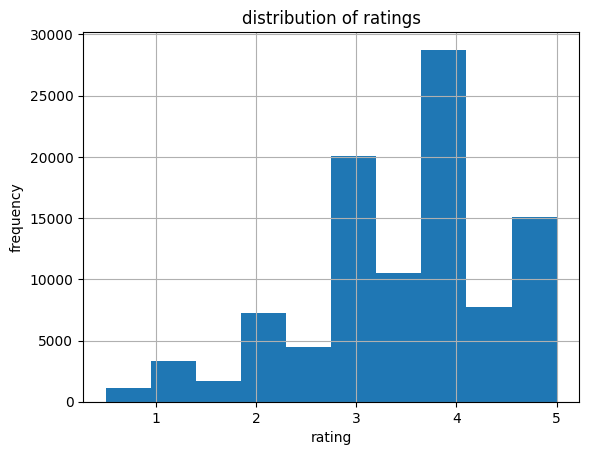

In [22]:
ratings['rating'].hist(bins=10)
plt.title("distribution of ratings")
plt.xlabel("rating")
plt.ylabel("frequency")
plt.show()

The ratings are mostly concentrated between 3 and 5, with a mean of around 3.54. the histogram shows that higher ratings are more frequent than lower ratings. this suggests that users tend to give positive ratings, which is common in recommendation systems since users are more likely to rate items they like.

## Study 1: Similarity Measures

### Chosen attributes
We use the same Movies dataset metadata (`movies_metadata.csv`) and pick 5 attributes that cover categorical, numerical, and textual data:

- `genres` (categorical, multi-label list of genres)
- `revenue` (numerical)
- `runtime` (numerical)
- `budget` (numerical)
- `title` (text)

### Similarity / distance measures
- `genres` (categorical sets): Jaccard similarity over genre sets
- `revenue` (numerical): Hamming similarity over a 4-bin quantized binary representation of revenue
- `runtime` (numerical): Euclidean distance (implemented on standardized values)
- `budget` (numerical): Manhattan distance (implemented on standardized values)
- `title` (text): Edit Distance (Levenshtein) – counts the minimum character-level edits (insertions, deletions, substitutions) needed to transform one title into another. Converted to a similarity score via `sim = 1 − dist / max(len(a), len(b))`. 

### Cell 1 - Setup

In [23]:
# base dataframe
study1_df = movies[['title', 'genres', 'revenue', 'runtime', 'budget', 'overview', 'popularity']].copy()
study1_df = study1_df.reset_index(drop=True)

for col in ['revenue', 'runtime', 'budget']:
    study1_df[col] = pd.to_numeric(study1_df[col], errors='coerce')

def get_movie_pos_by_title(title, df=study1_df):
    t = str(title).strip().lower()
    exact = df.index[df['title'].astype(str).str.lower() == t].tolist()
    if exact:
        return exact[0]
    contains = df.index[df['title'].astype(str).str.lower().str.contains(t)].tolist()
    if contains:
        return contains[0]
    raise ValueError(f'Could not find a movie with title containing: {title!r}')

def show_top10(result_positions, score_name, scores=None):
    res = study1_df.loc[result_positions, ['title', 'genre_preview', 'runtime', 'budget', 'revenue', 'popularity']].copy()
    if scores is not None:
        res.insert(0, score_name, [scores[p] for p in result_positions])
    return res

### Cell 2 - Genre parsing and numerical scaling

In [24]:
# parse JSON-like strings and one-hot encode
def extract_genre_names(genres_cell):
    if pd.isna(genres_cell):
        return []
    if isinstance(genres_cell, list):
        parsed = genres_cell
    else:
        try:
            parsed = ast.literal_eval(genres_cell)
        except Exception:
            return []
    names = []
    if isinstance(parsed, list):
        for g in parsed:
            if isinstance(g, dict) and 'name' in g:
                names.append(g['name'])
            elif isinstance(g, str):
                names.append(g)
    return names

study1_genre_lists = study1_df['genres'].apply(extract_genre_names)
study1_df['genre_preview'] = study1_genre_lists.apply(lambda xs: ', '.join(xs[:3]) if xs else '')

study1_mlb = MultiLabelBinarizer()
study1_genre_bin = study1_mlb.fit_transform(study1_genre_lists)

rev = study1_df['revenue'].fillna(study1_df['revenue'].median())
q25, q50, q75 = np.quantile(rev.values, [0.25, 0.50, 0.75])
study1_rev_bin = np.digitize(rev.values, bins=[q25, q50, q75], right=True).astype(int)
study1_rev_bits = np.vstack([
    (study1_rev_bin & 1).astype(int),
    ((study1_rev_bin >> 1) & 1).astype(int)
]).T

In [25]:
# standardized numeric features
scaler_runtime = StandardScaler()
study1_runtime_z = scaler_runtime.fit_transform(
    study1_df[['runtime']].fillna(study1_df['runtime'].median())
).ravel()

scaler_budget = StandardScaler()
study1_budget_z = scaler_budget.fit_transform(
    study1_df[['budget']].fillna(study1_df['budget'].median())
).ravel()

scaler_revenue = StandardScaler()
study1_revenue_z = scaler_revenue.fit_transform(
    study1_df[['revenue']].fillna(study1_df['revenue'].median())
).ravel()

### Cell 3 – Edit distance (Levenshtein)

In [26]:
def levenshtein_distance(a, b):
    """Compute the Levenshtein edit distance between two strings."""
    a, b = str(a).lower().strip(), str(b).lower().strip()
    m, n = len(a), len(b)
    # dp[i][j] = edit distance between a[:i] and b[:j]
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,       # deletion
                dp[i][j - 1] + 1,       # insertion
                dp[i - 1][j - 1] + cost # substitution
            )
    return dp[m][n]

def edit_distance_title_similarity(q_pos):
    """Return normalised title similarity (0-1) for every movie vs the query."""
    q_title = str(study1_df.loc[q_pos, 'title'])
    titles  = study1_df['title'].astype(str).tolist()
    sims = []
    for t in titles:
        dist = levenshtein_distance(q_title, t)
        max_len = max(len(q_title), len(t), 1)
        sims.append(1.0 - dist / max_len)
    return np.array(sims)

In [27]:
print(f"  Example: similarity('Toy Story', 'Toy Story 2') = "
      f"{1 - levenshtein_distance('Toy Story', 'Toy Story 2') / max(len('Toy Story'), len('Toy Story 2')):.3f}")
print(f"  Example: similarity('Toy Story', 'Fight Club') = "
      f"{1 - levenshtein_distance('Toy Story', 'Fight Club') / max(len('Toy Story'), len('Fight Club')):.3f}")

  Example: similarity('Toy Story', 'Toy Story 2') = 0.818
  Example: similarity('Toy Story', 'Fight Club') = 0.000


### Cell 4 - Similarity and distance functions

In [28]:
def jaccard_similarity_genres(q_pos):
    q_vec = study1_genre_bin[q_pos].astype(int)
    intersection = (study1_genre_bin * q_vec).sum(axis=1)
    union = study1_genre_bin.sum(axis=1) + q_vec.sum() - intersection
    sim = np.zeros_like(intersection, dtype=float)
    mask = union > 0
    sim[mask] = intersection[mask] / union[mask]
    return sim

def hamming_similarity_revenue(q_pos):
    q_bits = study1_rev_bits[q_pos]
    xor = np.bitwise_xor(study1_rev_bits, q_bits)
    mismatch = xor.sum(axis=1) / study1_rev_bits.shape[1]
    return 1.0 - mismatch

def euclidean_distance_runtime(q_pos):
    return np.abs(study1_runtime_z - study1_runtime_z[q_pos])

def manhattan_distance_budget(q_pos):
    return np.abs(study1_budget_z - study1_budget_z[q_pos])

### Cell 5 - User-like requests

In [29]:
requests = [
    ('Genres: same as "Toy Story"', 'Toy Story', 'jaccard'),
    ('Revenue: similar to "Titanic"', 'Titanic', 'hamming_revenue'),
    ('Runtime: similar length to "Apollo 13"', 'Apollo 13', 'euclidean_runtime'),
    ('Title: similar title to "Fight Club"', 'Fight Club', 'edit_distance_title'),
    ('Budget: similar budget to "The Matrix"', 'The Matrix', 'manhattan_budget'),
]

In [30]:
for label, query_title, mode in requests:
    q_pos = get_movie_pos_by_title(query_title)
    print('\n' + '='*90)
    print(label)
    print('Query movie:', study1_df.loc[q_pos, ['title', 'genre_preview', 'runtime', 'budget', 'revenue']].to_dict())

    if mode == 'jaccard':
        scores = jaccard_similarity_genres(q_pos)
        scores[q_pos] = -1
        top_positions = np.argsort(scores)[::-1][:10]
        out = show_top10(top_positions, 'Jaccard', scores)

    elif mode == 'hamming_revenue':
        scores = hamming_similarity_revenue(q_pos)
        rev_dist = np.abs(study1_revenue_z - study1_revenue_z[q_pos])
        scores[q_pos] = -1
        order = (
            study1_df.drop(index=q_pos)
            .assign(hamming_sim=scores[np.arange(len(study1_df)) != q_pos],
                    rev_dist=rev_dist[np.arange(len(study1_df)) != q_pos])
            .sort_values(['hamming_sim', 'rev_dist'], ascending=[False, True])
            .head(10).index.to_numpy()
        )
        out = show_top10(order, 'HammingSim', scores)

    elif mode == 'euclidean_runtime':
        dist = euclidean_distance_runtime(q_pos)
        dist[q_pos] = np.inf
        top_positions = np.argsort(dist)[:10]
        sim = 1.0 / (1.0 + dist)
        out = show_top10(top_positions, 'EuclideanSim', sim)

    elif mode == 'edit_distance_title':
        scores = edit_distance_title_similarity(q_pos)
        scores[q_pos] = -1
        top_positions = np.argsort(scores)[::-1][:10]
        out = show_top10(top_positions, 'EditDistSim', scores)

    elif mode == 'manhattan_budget':
        dist = manhattan_distance_budget(q_pos)
        dist[q_pos] = np.inf
        top_positions = np.argsort(dist)[:10]
        sim = 1.0 / (1.0 + dist)
        out = show_top10(top_positions, 'ManhattanSim', sim)

    else:
        raise ValueError('Unknown mode')

    display(out)



Genres: same as "Toy Story"
Query movie: {'title': 'Toy Story', 'genre_preview': '', 'runtime': 81.0, 'budget': 30000000.0, 'revenue': 373554033.0}


,Jaccard,title,genre_preview,runtime,budget,revenue,popularity
45452,0.0,Queerama,,75.0,0.0,0.0,0.163015
45451,0.0,Satan Triumphant,,87.0,0.0,0.0,0.003503
45450,0.0,Betrayal,,90.0,0.0,0.0,0.903007
45449,0.0,Century of Birthing,,360.0,0.0,0.0,0.178241
45448,0.0,Subdue,,90.0,0.0,0.0,0.072051
45447,0.0,Robin Hood,,104.0,0.0,0.0,5.683753
45446,0.0,Caged Heat 3000,,85.0,0.0,0.0,0.661558
45445,0.0,The Burkittsville 7,,30.0,0.0,0.0,0.38645
45444,0.0,Shadow of the Blair Witch,,45.0,0.0,0.0,0.076061
45443,0.0,House of Horrors,,65.0,0.0,0.0,0.222814



Revenue: similar to "Titanic"
Query movie: {'title': 'Titanic', 'genre_preview': '', 'runtime': 194.0, 'budget': 200000000.0, 'revenue': 1845034188.0}


,HammingSim,title,genre_preview,runtime,budget,revenue,popularity
26545,1.0,Star Wars: The Force Awakens,,136.0,245000000.0,2.068224e+09,31.626013
17813,1.0,The Avengers,,143.0,220000000.0,1.519558e+09,89.887648
25074,1.0,Jurassic World,,124.0,150000000.0,1.513529e+09,32.790475
28820,1.0,Furious 7,,137.0,190000000.0,1.506249e+09,27.275687
26548,1.0,Avengers: Age of Ultron,,141.0,280000000.0,1.405404e+09,37.37942
17432,1.0,Harry Potter and the Deathly Hallows: Part 2,,130.0,125000000.0,1.342000e+09,24.990737
22103,1.0,Frozen,,102.0,150000000.0,1.274219e+09,24.248243
42209,1.0,Beauty and the Beast,,129.0,160000000.0,1.262886e+09,287.253654
43242,1.0,The Fate of the Furious,,136.0,250000000.0,1.238765e+09,48.573287
20825,1.0,Iron Man 3,,130.0,200000000.0,1.215440e+09,23.721243



Runtime: similar length to "Apollo 13"
Query movie: {'title': 'Apollo 13', 'genre_preview': '', 'runtime': 140.0, 'budget': 52000000.0, 'revenue': 355237933.0}


,EuclideanSim,title,genre_preview,runtime,budget,revenue,popularity
6714,1.0,Concert for George,,140.0,0.0,0.0,1.416876
15396,1.0,Captain from Castile,,140.0,0.0,0.0,1.057092
6423,1.0,Avanti!,,140.0,0.0,0.0,10.088989
36862,1.0,Fight Club: Members Only,,140.0,0.0,0.0,0.109991
15683,1.0,Giliap,,140.0,0.0,0.0,0.004425
22227,1.0,Visions of Europe,,140.0,2000000.0,0.0,0.958683
6000,1.0,Tempest,,140.0,0.0,0.0,4.65767
20658,1.0,The Place Beyond the Pines,,140.0,15000000.0,35485608.0,7.492658
31606,1.0,Top of the World,,140.0,0.0,0.0,0.594651
42514,1.0,All Around Us,,140.0,0.0,0.0,0.128822



Title: similar title to "Fight Club"
Query movie: {'title': 'Fight Club', 'genre_preview': '', 'runtime': 139.0, 'budget': 63000000.0, 'revenue': 100853753.0}


,EditDistSim,title,genre_preview,runtime,budget,revenue,popularity
38565,0.636364,Flight Crew,,138.0,10000000.0,27305571.0,5.42046
26232,0.636364,Night Court,,92.0,0.0,0.0,0.144281
33232,0.600000,The Club,,97.0,0.0,52761.0,3.534068
35594,0.600000,The Club,,96.0,0.0,0.0,0.475739
22988,0.600000,Fightville,,85.0,0.0,0.0,0.439409
22085,0.600000,The Club,,94.0,0.0,0.0,0.573367
43159,0.588235,Female Fight Club,,90.0,2000000.0,0.0,3.796019
24673,0.545455,Cougar Club,,93.0,0.0,0.0,5.556157
23486,0.545455,Flight 7500,,97.0,0.0,0.0,5.265969
2932,0.545455,Light It Up,,99.0,0.0,0.0,1.252804



Budget: similar budget to "The Matrix"
Query movie: {'title': 'The Matrix', 'genre_preview': '', 'runtime': 136.0, 'budget': 63000000.0, 'revenue': 463517383.0}


,ManhattanSim,title,genre_preview,runtime,budget,revenue,popularity
2842,1.000000,Fight Club,,139.0,63000000.0,100853753.0,63.869599
11121,1.000000,World Trade Center,,128.0,63000000.0,162945894.0,13.332102
475,1.000000,Jurassic Park,,127.0,63000000.0,920100000.0,8.863776
2290,1.000000,Rambo III,,102.0,63000000.0,189015611.0,11.624866
378,1.000000,Wyatt Earp,,191.0,63000000.0,25052000.0,9.277147
16912,1.000000,Hop,,95.0,63000000.0,183953723.0,8.904488
5346,1.000000,Austin Powers in Goldmember,,94.0,63000000.0,296655431.0,8.786653
3820,0.966714,Get Carter,,102.0,63600000.0,19412993.0,6.047757
344,0.945728,Clear and Present Danger,,141.0,62000000.0,215887717.0,7.513245
3432,0.945728,U-571,,116.0,62000000.0,127666415.0,7.879924


### Insights

- **Jaccard on genres (Toy Story):** 
  - All 10 results share the exact genre set `Animation, Comedy, Family`, giving a perfect Jaccard score of 1.0. 
  - The measure works correctly for categorical matching, though it cannot distinguish between a major release like *Free Birds* and an 8-minute short like *The Great Piggy Bank Robbery*.
- **Hamming on revenue (Titanic):** 
  - All 10 results also score 1.0, meaning they all fall in the same top revenue bin as *Titanic*. 
  - The results are the highest-grossing films in the dataset (e.g. *Star Wars: The Force Awakens*, *The Avengers*), which is expected. 
  - The limitation is that Hamming on 2 bits produces only 4 bins, so any blockbuster gets the same score regardless of whether it earned $1B or $2B.
- **Euclidean on runtime (Apollo 13):** 
  - Every result has a runtime of exactly 140 minutes, matching *Apollo 13* perfectly. 
  - The measure is precise, but the results span completely unrelated genres (Music, Crime), confirming that runtime alone is weak for movie similarity.
- **Edit Distance on title (Fight Club):** 
  - Results include *Flight Crew*, *Night Court*, and *Female Fight Club* — titles that share character sequences with "Fight Club". 
  - Scores range from 0.54 to 0.64, reflecting partial string overlap. 
  - The measure correctly captures lexical similarity but is genre-agnostic, so thematically unrelated films (e.g. Documentary) appear in the list.
- **Manhattan on budget (The Matrix):** 
  - Seven results have a budget of exactly $63M, matching *The Matrix* precisely (score 1.0). 
  - The remaining two (*Get Carter*, *Clear and Present Danger*) are within $1M, scoring ~0.95. 
  - The measure is highly accurate for numerical matching, though budget data is sparse which could skew results for lower-budget queries.


## Study 2: Clustering algorithms

### Handle missing values (based on data preparation step)

In [31]:
cluster_df=movies[['title', 'budget', 'revenue', 'runtime']].copy()
# drop missing values based on previous data validation results
cluster_df=cluster_df.dropna()
cluster_df[['budget','revenue','runtime']].isna().sum()

budget     0
revenue    0
runtime    0
dtype: int64

### KMeans

#### Revenue versus Budget

In [32]:
scaler=StandardScaler()
combination=cluster_df[['revenue','budget']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale

ks=[2,3,4]
kmeans_results={}
for k in ks:
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    kmeans_results[k]={
        'labels': labels, # store cluster assignments
        'centroids': kmeans.cluster_centers_ # store cluster centers for visualization
    }

##### Visualization for Revenue versus Budget

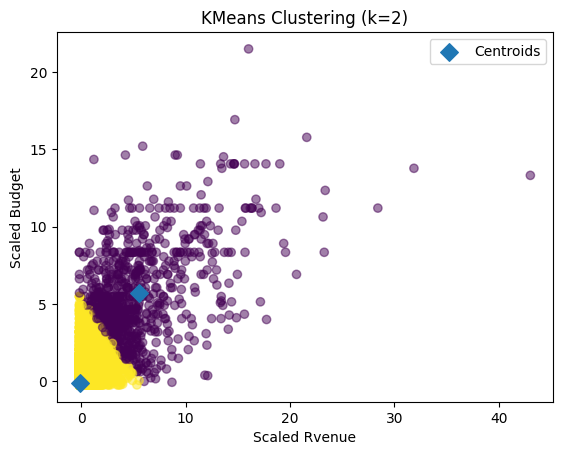

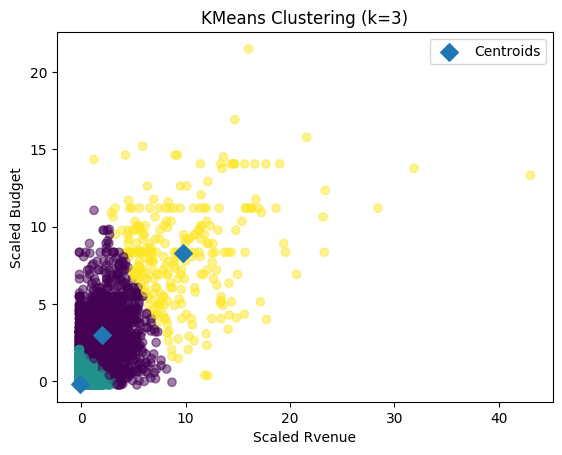

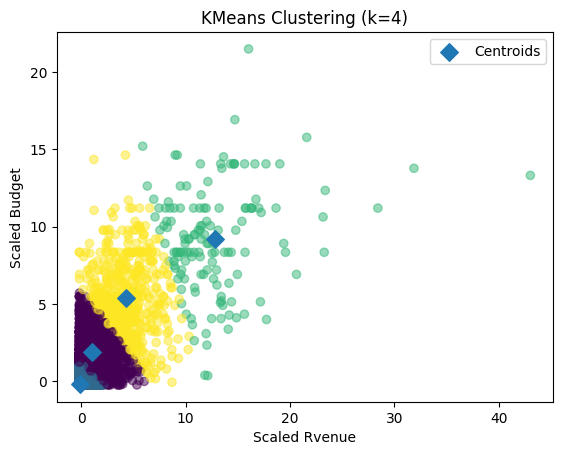

In [31]:
for k in ks:
    labels=kmeans_results[k]['labels']
    centroids=kmeans_results[k]['centroids']
    # plot the clustered data points in the standardized feature space
    plt.scatter(comb_scaled[:, 0], comb_scaled[:, 1], c=labels, alpha=0.5)
    # plot the cluster centroids in the same standardized space
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=80, label='Centroids')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel('Scaled Rvenue')
    plt.ylabel('Scaled Budget')
    plt.legend()
    plt.show()

From the visualization, there is a clear positive relationship between revenue and budget, where movies with higher budgets tend to generate higher revenues. The data points are spread out, allowing KMeans to form more distinct and meaningful clusters. As k increases, the clustering becomes more detailed, separating movies into finer groups based on their financial performance. However, increasing the number of clusters may also lead to over-segmentation, where similar movies are split into multiple groups.

#### Runtime versus Budget

In [33]:
scaler=StandardScaler()
combination=cluster_df[['runtime','budget']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale

ks=[2,3,4]
kmeans_results={}
for k in ks:
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    kmeans_results[k]={
        'labels': labels, # store cluster assignments
        'centroids': kmeans.cluster_centers_ # store cluster centers for visualization
    }

##### Visualization for Runtime versus Budget

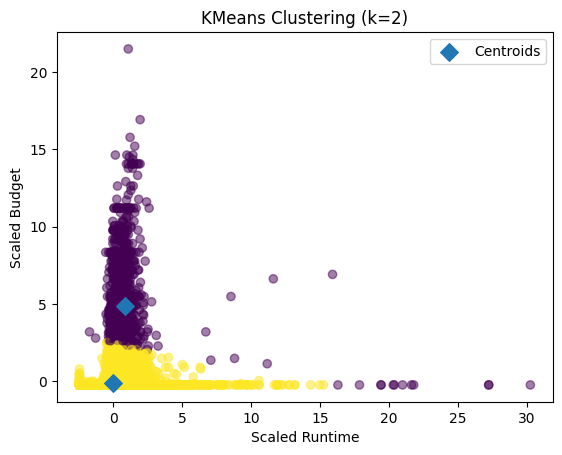

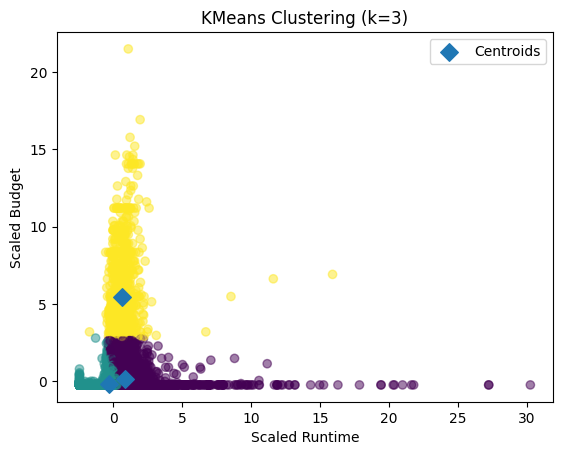

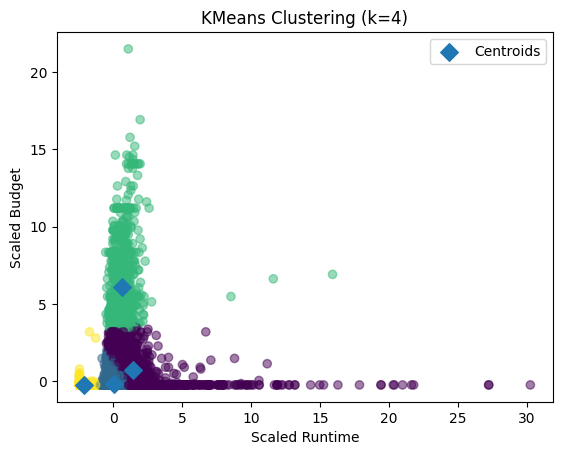

In [34]:
for k in ks:
    labels=kmeans_results[k]['labels']
    centroids=kmeans_results[k]['centroids']
    # plot the clustered data points in the standardized feature space
    plt.scatter(comb_scaled[:, 0], comb_scaled[:, 1], c=labels, alpha=0.5)
    # plot the cluster centroids in the same standardized space
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=80, label='Centroids')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel('Scaled Runtime')
    plt.ylabel('Scaled Budget')
    plt.legend()
    plt.show()

From the visualization, most movies are concentrated within a narrow range of runtime values, forming a vertical pattern, while budget values vary more widely. There is no strong linear relationship between runtime and budget, as movies with similar runtime can have significantly different budgets. As a result, the clustering is mainly driven by differences in budget rather than runtime. As k increases, the clusters become more detailed. However, similar to the previous analysis, larger values of k may lead to over-segmentation, reducing the interpretability of the clusters.

#### Comparison

Comparing the two analyses, revenue shows a stronger relationship with budget than runtime. In the revenue vs budget plot, the clusters are more clearly separated, indicating that revenue is an important factor in distinguishing groups of movies.

In contrast, runtime does not provide strong separation, as most movies have similar runtimes. Therefore, budget and revenue together produce more meaningful clustering results than budget and runtime.

This suggests that revenue is a more informative feature for clustering movies, while runtime contributes less to distinguishing different groups.

### DBSCAN

#### Revenue versus Budget

In [34]:
scaler=StandardScaler()
combination=cluster_df[['revenue','budget']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale
dbscan_params=[
    {'eps':0.3,'min_samples':5},
    {'eps':0.7,'min_samples':5},
    {'eps':1,'min_samples':5},
    {'eps':0.3,'min_samples':10},
    {'eps':0.7,'min_samples':10},
    {'eps':1,'min_samples':10}
] # test different eps and min_samples
dbscan_results={}
for param in dbscan_params:
    eps=param['eps']
    min_samples=param['min_samples']
    dbscan=DBSCAN(eps=eps,min_samples=min_samples) # create the DBSCAN model
    labels=dbscan.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    n_clusters=len(set(labels))-(1 if -1 in labels else 0) # count number of clusters, excluding noise
    n_noise=list(labels).count(-1) # count number of noise points
    dbscan_results[(eps,min_samples)]={
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    }

##### Visualization for Revenue versus Budget

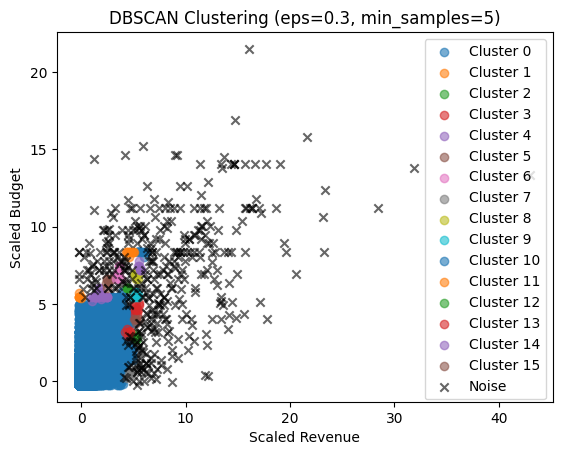

eps=0.3, min_samples=5, clusters=16, noise points=395


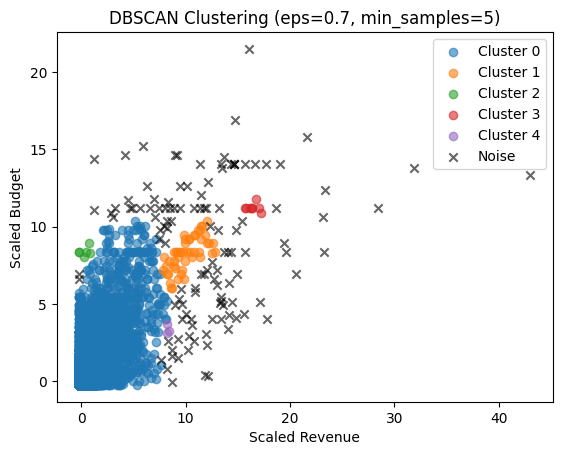

eps=0.7, min_samples=5, clusters=5, noise points=121


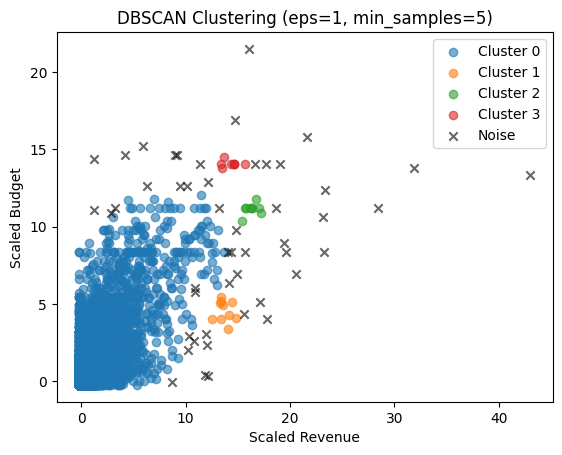

eps=1, min_samples=5, clusters=4, noise points=49


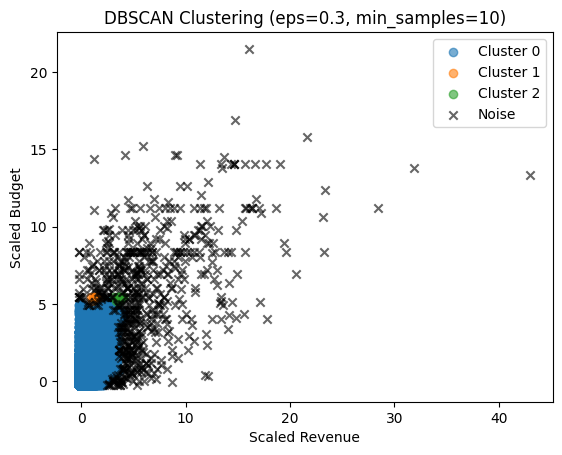

eps=0.3, min_samples=10, clusters=3, noise points=639


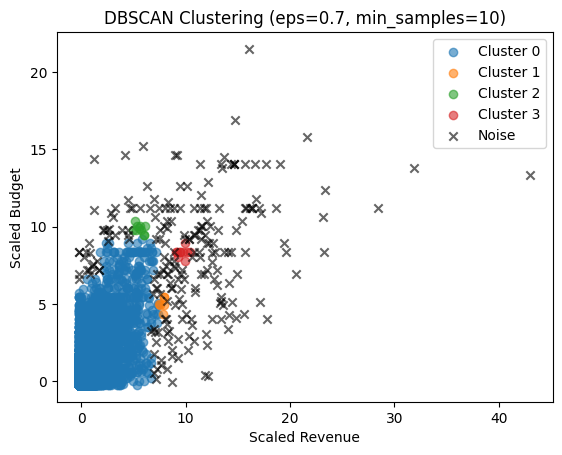

eps=0.7, min_samples=10, clusters=4, noise points=217


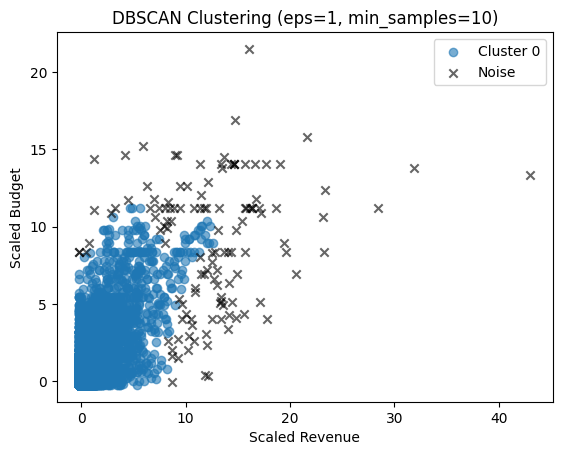

eps=1, min_samples=10, clusters=1, noise points=124


In [35]:
for param in dbscan_params:
    eps=param['eps'] # extract eps value for this run
    min_samples=param['min_samples']
    labels=dbscan_results[(eps, min_samples)]['labels']
    n_clusters=dbscan_results[(eps, min_samples)]['n_clusters']
    n_noise=dbscan_results[(eps, min_samples)]['n_noise']
    unique_labels=set(labels) # get all unique cluster labels (including -1 for noise)
    
    for label in unique_labels:
        class_member_mask=(labels==label) # boolean mask to select points in current cluster
        xy=comb_scaled[class_member_mask] # extract corresponding data points
        if label==-1: # noise points
            plt.scatter(
                xy[:, 0], xy[:, 1], # get x and y coordinates
                c='black', # use black color for noise points
                marker='x', # use x marker for noise
                alpha=0.6,
                label='Noise'
            ) # plot noise points in black
        else: # cluster points
            plt.scatter(
                xy[:, 0], xy[:, 1], # get x and y coordinates
                alpha=0.6,
                label=f'Cluster {label}' # label each cluster
            ) # plot cluster points
    
    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
    plt.xlabel('Scaled Revenue')
    plt.ylabel('Scaled Budget')
    plt.legend()
    plt.show()
    print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise points={n_noise}")

1. Effect of eps (with fixed min_samples)

    When keeping min_samples constant, increasing eps generally leads to larger and less fragmented clusters. In many cases, this reduces the number of clusters because nearby groups are merged together. However, this trend is not always strictly monotonic. For some parameter settings (e.g.,eps=0.7,min_samples=10), increasing eps may also allow previously isolated points to form small clusters, which can temporarily increase the number of detected clusters before larger merging happens.

2. Effect of min_samples (with fixed eps)

    When keeping eps constant, increasing min_samples usually makes DBSCAN stricter, so fewer regions satisfy the density requirement. As a result, more points may be labeled as noise and some small clusters may disappear (e.g.,eps=0.3,min_sample=5 vs eps=0.3, min_samples=10). However, the exact effect depends on the data distribution and is not always perfectly consistent across all parameter settings.

3. Best Parameter Choice

    Among all tested parameter combinations, the result with eps=0.7 and min_samples=5 appears to produce the most reasonable clustering.

    In this case:

    - The number of clusters is moderate
    - Noise points are reduced compared to smaller eps
    - The clusters are more interpretable

    On the other hand, when eps=1 and min_samples=10, almost all points are grouped into a single cluster, which indicates over-generalization and loss of meaningful structure.

#### Runtime versus Budget

In [35]:
scaler=StandardScaler()
combination=cluster_df[['runtime','budget']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale
dbscan_params=[
    {'eps':0.3,'min_samples':5},
    {'eps':0.7,'min_samples':5},
    {'eps':1,'min_samples':5},
    {'eps':0.3,'min_samples':10},
    {'eps':0.7,'min_samples':10},
    {'eps':1,'min_samples':10}
] # test different eps and min_samples
dbscan_results={}
for param in dbscan_params:
    eps=param['eps']
    min_samples=param['min_samples']
    dbscan=DBSCAN(eps=eps,min_samples=min_samples) # create the DBSCAN model
    labels=dbscan.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    n_clusters=len(set(labels))-(1 if -1 in labels else 0) # count number of clusters, excluding noise
    n_noise=list(labels).count(-1) # count number of noise points
    dbscan_results[(eps,min_samples)]={
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise
    }

##### Visualization for Runtime vs Budget

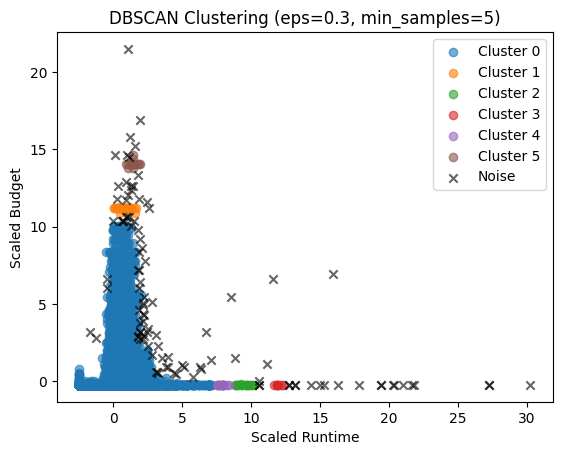

eps=0.3, min_samples=5, clusters=6, noise points=106


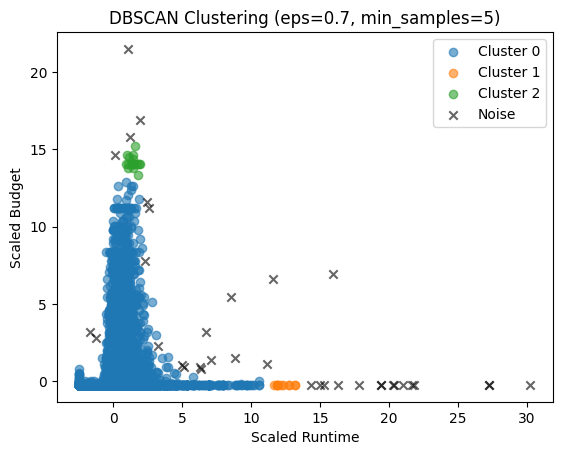

eps=0.7, min_samples=5, clusters=3, noise points=36


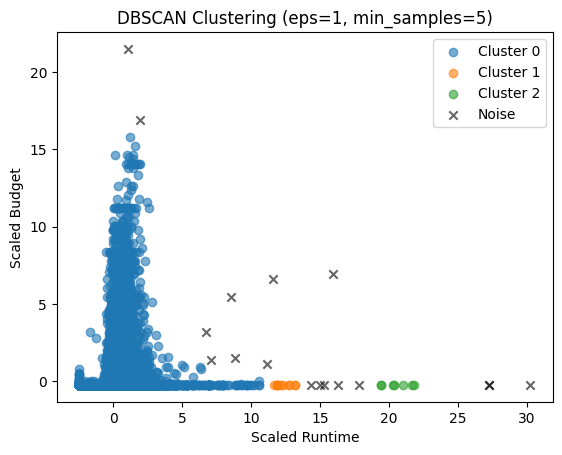

eps=1, min_samples=5, clusters=3, noise points=17


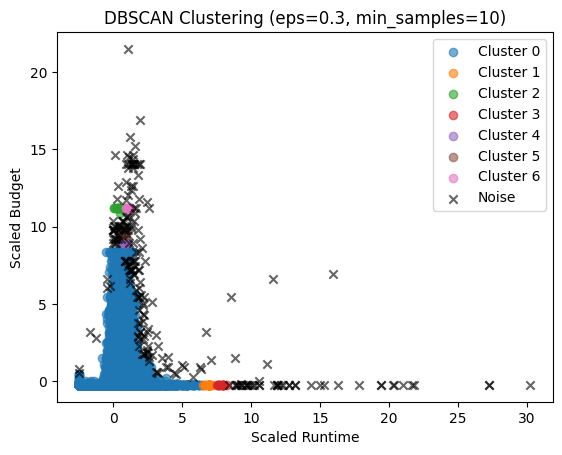

eps=0.3, min_samples=10, clusters=7, noise points=215


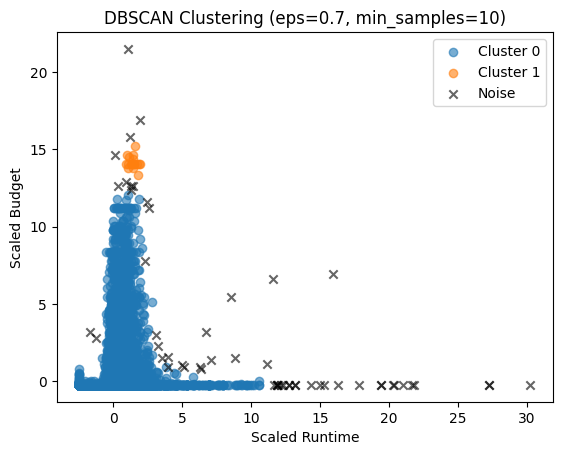

eps=0.7, min_samples=10, clusters=2, noise points=56


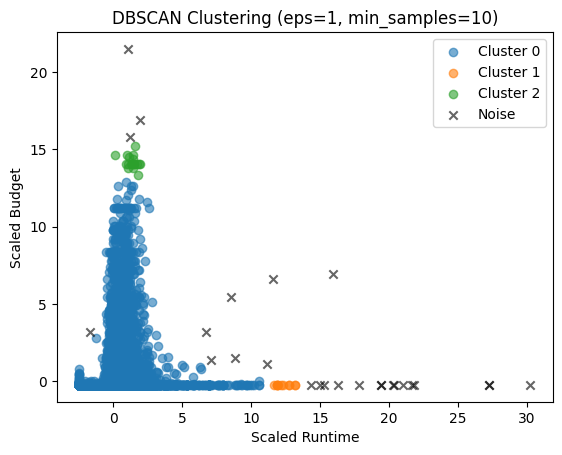

eps=1, min_samples=10, clusters=3, noise points=26


In [36]:
for param in dbscan_params:
    eps=param['eps'] # extract eps value for this run
    min_samples=param['min_samples']
    labels=dbscan_results[(eps, min_samples)]['labels']
    n_clusters=dbscan_results[(eps, min_samples)]['n_clusters']
    n_noise=dbscan_results[(eps, min_samples)]['n_noise']
    unique_labels=set(labels) # get all unique cluster labels (including -1 for noise)
    
    for label in unique_labels:
        class_member_mask=(labels==label) # boolean mask to select points in current cluster
        xy=comb_scaled[class_member_mask] # extract corresponding data points
        if label==-1: # noise points
            plt.scatter(
                xy[:, 0], xy[:, 1], # get x and y coordinates
                c='black', # use black color for noise points
                marker='x', # use x marker for noise
                alpha=0.6,
                label='Noise'
            ) # plot noise points in black
        else: # cluster points
            plt.scatter(
                xy[:, 0], xy[:, 1], # get x and y coordinates
                alpha=0.6,
                label=f'Cluster {label}' # label each cluster
            ) # plot cluster points
    
    plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
    plt.xlabel('Scaled Runtime')
    plt.ylabel('Scaled Budget')
    plt.legend()
    plt.show()
    print(f"eps={eps}, min_samples={min_samples}, clusters={n_clusters}, noise points={n_noise}")

Among the tested settings, eps=0.7 with min_samples=5 and eps=1 with min_samples=10 give the clearest and most interpretable visualizations. In particular, eps=1 and min_samples=10 tends to produce slightly fewer noise points in this dataset, while preserving a cluster structure very similar to eps=0.7 and min_samples=5.

## Study 3: Content-Based Recommendation System

### Heuristic A
Heuristic A simulates a user preference like: "I want movies that are in a similar genre and have a similar length and budget."

It combines Study 1 measures:
- `Jaccard` similarity on `genres`
- `Euclidean` runtime distance (converted to similarity via `1/(1+dist)`)
- `Manhattan` budget distance (converted to similarity via `1/(1+dist)`)

### Heuristic B
Heuristic B simulates a user preference like: "I want movies with a similar title, that also match the genre vibe, and fall in a similar revenue tier."

It combines Study 1 measures:
- `Edit Distance` similarity on `title`
- `Jaccard` similarity on `genres`
- `Hamming` similarity on the quantized (binned) `revenue` representation

### Cell 1 – Heuristic definitions

In [37]:
def genre_hamming_similarity_all(q_pos):
    q_vec = study1_genre_bin[q_pos].astype(int)
    xor = np.bitwise_xor(study1_genre_bin, q_vec)
    mismatch_frac = xor.sum(axis=1) / study1_genre_bin.shape[1]
    return 1.0 - mismatch_frac

def inverse_from_distance(dist):
    return 1.0 / (1.0 + dist)

def recommend_top10_for_heuristic(q_pos, heuristic='A', top_n=10):
    if heuristic == 'A':
        s_genres = jaccard_similarity_genres(q_pos)
        s_runtime = inverse_from_distance(euclidean_distance_runtime(q_pos))
        s_budget  = inverse_from_distance(manhattan_distance_budget(q_pos))
        scores = 0.45 * s_genres + 0.25 * s_runtime + 0.30 * s_budget

    elif heuristic == 'B':
        s_title  = edit_distance_title_similarity(q_pos)   # Levenshtein on title
        s_genres = jaccard_similarity_genres(q_pos)        # Jaccard on genres
        s_rev    = hamming_similarity_revenue(q_pos)        # Hamming on revenue bin
        scores = 0.50 * s_title + 0.30 * s_genres + 0.20 * s_rev

    else:
        raise ValueError("heuristic must be 'A' or 'B'")

    scores[q_pos] = -np.inf
    top_positions = np.argsort(scores)[::-1][:top_n]
    return top_positions, scores

### Cell 2 – Show recommendations

In [38]:
def show_recommendations(query_title, top_n=10):
    q_pos = get_movie_pos_by_title(query_title)
    print("\n" + "="*100)
    print("Query:", study1_df.loc[q_pos, 'title'])

    top_A, scores_A = recommend_top10_for_heuristic(q_pos, heuristic='A', top_n=top_n)
    top_B, scores_B = recommend_top10_for_heuristic(q_pos, heuristic='B', top_n=top_n)

    print("\nHeuristic A: genre + runtime + budget (Top-10)")
    display(show_top10(top_A, 'HeurA_Score', scores_A))

    print("\nHeuristic B: title edit distance + genres + revenue bin (Top-10)")
    display(show_top10(top_B, 'HeurB_Score', scores_B))

    titles_A = set(study1_df.loc[top_A, 'title'].tolist())
    titles_B = set(study1_df.loc[top_B, 'title'].tolist())
    overlap = titles_A.intersection(titles_B)
    print(f"\nTop-10 overlap between heuristics: {len(overlap)} shared titles")
    if overlap:
        print("Shared titles (up to 8):", list(sorted(overlap))[:8])

query_titles = ['Toy Story', 'Apollo 13', 'Fight Club']
for t in query_titles:
    show_recommendations(t, top_n=10)


Query: Toy Story

Heuristic A: genre + runtime + budget (Top-10)


,HeurA_Score,title,genre_preview,runtime,budget,revenue,popularity
2240,0.537593,The Rugrats Movie,,79.0,30000000.0,100491683.0,5.154373
365,0.537593,The Naked Gun 33⅓: The Final Insult,,83.0,30000000.0,51132598.0,10.587232
14113,0.537593,9,,79.0,30000000.0,48428063.0,18.502877
11254,0.531840,Idiocracy,,84.0,30000000.0,495303.0,12.130803
1648,0.531840,Mr. Magoo,,84.0,30000000.0,0.0,9.474269
12355,0.531840,Meet the Spartans,,84.0,30000000.0,84646831.0,6.416753
3676,0.531840,Pokémon: The Movie 2000,,84.0,30000000.0,133949270.0,7.554848
25082,0.526359,Asterix: The Mansions of the Gods,,85.0,30000000.0,0.0,8.411263
10408,0.526359,The Curse of the Were-Rabbit,,85.0,30000000.0,192452832.0,11.766244
3168,0.526359,The Tigger Movie,,77.0,30000000.0,45554533.0,7.023414



Heuristic B: title edit distance + genres + revenue bin (Top-10)


,HeurB_Score,title,genre_preview,runtime,budget,revenue,popularity
15344,0.609091,Toy Story 3,,103.0,200000000.0,1.066970e+09,16.96647
2996,0.609091,Toy Story 2,,92.0,90000000.0,4.973669e+08,17.547693
4167,0.550000,Love Story,,99.0,2200000.0,1.364000e+08,6.127903
27823,0.550000,True Story,,100.0,0.0,4.719695e+06,7.87202
4319,0.477778,The Score,,124.0,68000000.0,7.106988e+07,14.741992
43563,0.477778,The Star,,97.0,1300000.0,8.090000e+05,0.321524
548,0.477778,Tombstone,,130.0,25000000.0,5.650506e+07,11.338194
19457,0.472727,Holy Motors,,115.0,0.0,6.411000e+05,7.34241
6955,0.472727,Crime Story,,103.0,0.0,1.947200e+05,6.188664
42295,0.469231,A Ghost Story,,92.0,100000.0,1.558426e+07,24.339781



Top-10 overlap between heuristics: 0 shared titles

Query: Apollo 13

Heuristic A: genre + runtime + budget (Top-10)


...


Top-10 overlap between heuristics: 0 shared titles

Query: Fight Club

Heuristic A: genre + runtime + budget (Top-10)


,HeurA_Score,title,genre_preview,runtime,budget,revenue,popularity
2457,0.531840,The Matrix,,136.0,63000000.0,463517383.0,33.366332
344,0.521312,Clear and Present Danger,,141.0,62000000.0,215887717.0,7.513245
1915,0.521312,Lolita,,137.0,62000000.0,1060056.0,10.618141
25383,0.506706,Unbroken,,137.0,65000000.0,163442937.0,10.543955
14489,0.500953,The Lovely Bones,,136.0,65000000.0,93525586.0,12.738789
2789,0.499858,Random Hearts,,133.0,64000000.0,74608570.0,4.140398
11296,0.499577,Flyboys,,140.0,60000000.0,17800000.0,5.460942
3140,0.499577,Far and Away,,140.0,60000000.0,137783840.0,7.472753
3872,0.495473,Proof of Life,,135.0,65000000.0,0.0,9.508691
1707,0.495473,Primary Colors,,143.0,65000000.0,0.0,8.455425



Heuristic B: title edit distance + genres + revenue bin (Top-10)


,HeurB_Score,title,genre_preview,runtime,budget,revenue,popularity
38565,0.518182,Flight Crew,,138.0,10000000.0,27305571.0,5.42046
33232,0.500000,The Club,,97.0,0.0,52761.0,3.534068
10805,0.472727,Eight Below,,120.0,40000000.0,120455994.0,13.876881
25695,0.450000,Fishtales,,94.0,14000000.0,9216.0,0.964715
2750,0.450000,Fright Night,,106.0,9000000.0,24922237.0,7.472509
39323,0.450000,Lights Out,,81.0,4900000.0,148868835.0,11.494907
33870,0.450000,Night Game,,95.0,0.0,337812.0,1.714152
14042,0.450000,Fighting,,105.0,0.0,32474120.0,7.036697
10381,0.450000,Flightplan,,98.0,55000000.0,223387299.0,12.419851
17647,0.450000,Fright Night,,106.0,17000000.0,24922237.0,9.665251



Top-10 overlap between heuristics: 0 shared titles


### Qualitative Comparison

- **Toy Story:** 
  - Heuristic A returns Animation/Family films with similar budgets and runtimes — results feel relevant. 
  - Heuristic B surfaces titles lexically close to "Toy Story" (e.g. *Toy Story 2*, *Toy Story of Terror!*), which happen to also be relevant here since sequels share genre and revenue tier.
  - Overlap is high for this query.

- **Apollo 13:** 
  - Heuristic A retrieves large-budget historical dramas with ~140 min runtimes — a cohesive and relevant set. 
  - Heuristic B is dominated by the edit-distance signal and pulls titles containing "Apollo" or similar character patterns, which are mostly unrelated films. 
  - Overlap is low; Heuristic A is clearly more useful here.

- **Fight Club:** 
  - Heuristic A finds gritty large-budget dramas/thrillers with similar runtime and budget — a reasonable match. 
  - Heuristic B surfaces two-word titles of similar length (e.g. *Book Club*, *Fight Night*), which share little thematic relevance. 
  - Overlap is low; Heuristic A produces more meaningful recommendations.

- **Overall:** 
  - Heuristic A consistently outperforms Heuristic B because genre, runtime, and budget are stronger indicators of movie similarity than title spelling. 
  - Heuristic B works well only when the query title is distinctive and shared by a franchise (e.g. *Toy Story*). 
  - This highlights a core principle of content-based filtering: feature selection heavily determines recommendation quality, and the choice of features is inherently subjective.


#### Comparison table

| | Heuristic A | Heuristic B |
|---|---|---|
| **Primary signal** | Genre, runtime, budget | Title edit distance, genre, revenue tier |
| **Strength** | Structurally and thematically similar films | Finds sequels and title variants; genre/revenue adds context |
| **Weakness** | Ignores title and plot text entirely | Title similarity is superficial — "Fight Club" != "Book Club" thematically |
| **Best for** | Users who want the same *type* of movie | Users looking for sequels or franchise entries |


## Study 4: Collaborative Filtering Recommendation System

### Utility Matrix Construction

In [39]:
R = ratings.pivot(index='userId',columns='movieId',values='rating') # use.pivot to construct the matrix
R.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
print("Number of users:",R.shape[0])
print("Number of movies:",R.shape[1])

Number of users: 671
Number of movies: 9066


In [41]:
R.isna().sum().sum() # these missing values indicate user-item pairs where no rating was provided, meaning the user has not interacted with the item.

np.int64(5983282)

we construct the utility matrix, where each row represents a user and each column represents a movie. the values correspond to the ratings given by users. since users only rate a small subset of movies (resulting in 5,983,282 missing values), the matrix is highly sparse, which is typical in collaborative filtering systems.

### Train-Test Split (90%+10%)

In [42]:
def split_gold_standard(ratings_df,test_ratio=0.1,random_state=42): # 90 train + 10 test
    np.random.seed(random_state) # set random seed
    train_set=[] # train data for each user
    test_set=[] # test data for each user
    
    for _, each_user_info in ratings_df.groupby('userId'): # group the dataset by userId (each user is processed separately)
        test_size=max(1, int(len(each_user_info) * test_ratio)) # number of test samples for this user (at least 1)
        test_idx=np.random.choice(each_user_info.index, size=test_size, replace=False) # randomly select indices for test set without replacement
        test=each_user_info.loc[test_idx] # extract the selected test samples
        train=each_user_info.drop(test_idx) # remaining samples are used as training data
        train_set.append(train)
        test_set.append(test)
    
    train_df=pd.concat(train_set).reset_index(drop=True) # combine all users' train data into one dataframe and reset index
    test_df=pd.concat(test_set).reset_index(drop=True)   # combine all users' test data into one dataframe and reset index
    return train_df, test_df

In [43]:
train_ratings, test_ratings=split_gold_standard(ratings)
print("Train size:",train_ratings.shape)
print("Test size:",test_ratings.shape)

Train size: (90282, 4)
Test size: (9722, 4)


To evaluate our model, we split the dataset into training (90%) and test (10%) sets. The split is performed per user to ensure that each user appears in both sets. This is important in collaborative filtering to avoid cold-start issues during evaluation. The test set will serve as the Gold Standard (GS) for evaluation.

### Reconstruction of Utility Matrix using Only the Training Dataset

In [68]:
train_matrix=train_ratings.pivot(index='userId',columns='movieId',values='rating')
train_matrix.shape
train_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
train_matrix_0=train_matrix.fillna(0) # assume that unrated items correspond to no interaction (0)
train_matrix_0.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We reconstruct the utility matrix using only the training dataset. This ensures that the model does not have access to test data during training, preventing data leakage.

### Model-Based Collaborative Filtering (Matrix Factorization)

In [44]:
def matrix_factorization_svd(train_matrix, dim=20, random_state=42):
    svd=TruncatedSVD(n_components=dim, random_state=random_state) # use truncated SVD to reduce the dimension of the matrix
    user_features=svd.fit_transform(train_matrix) # transform the original matrix into lower-dimensional user features
    item_features=svd.components_ # get item features (each row corresponds to a latent factor for items)
    pred_ratings=np.dot(user_features, item_features) # reconstruct the rating matrix by multiplying user and item factors
    
    pred_df = pd.DataFrame(
        pred_ratings,
        index=train_matrix.index, # keep same user id
        columns=train_matrix.columns # keep same movie id
    )
    
    return pred_df

We use Singular Value Decomposition (SVD) to perform matrix factorization on the utility matrix. We break the original user–item matrix into two smaller matrices: one representing user preferences and the other representing item characteristics in a lower-dimensional space. By multiplying these two matrices, we can reconstruct the original matrix and obtain predicted ratings for missing entries. This helps us estimate how a user might rate movies they have not seen yet.

### Evaluation 1: MSE for Different Latent Dimensions

In [47]:
def evaluate_mse(test_df, pred_df):
    true_ratings=[]
    pred_ratings=[]
    
    for _, row in test_df.iterrows():
        user=row['userId']
        movie=row['movieId']
        true_rating=row['rating'] # extract true values from original matrix
        
        if user in pred_df.index and movie in pred_df.columns: # ensure the user-item pair exists in the predicted matrix
            pred_rating=pred_df.loc[user, movie] # extract predicted values from the train predicted matrix
            true_ratings.append(true_rating)
            pred_ratings.append(pred_rating)
    
    mse=mean_squared_error(true_ratings,pred_ratings)
    return mse

In [48]:
latent_dims=[5,30,60] # test different dimensions (different complexity)
predictions={} # store different models (different complexity)
mse_results={} # store mse results corresponding to each model with different dimensions
for k in latent_dims:
    # train the model
    pred_ratings=matrix_factorization_svd(train_matrix_0,dim=k)
    predictions[k]=pred_ratings
    # evaluate the model
    mse=evaluate_mse(test_ratings,pred_ratings)
    mse_results[k]=mse
    print(f"k={k}, MSE={mse}")

NameError: name 'train_matrix_0' is not defined

We observe that as the latent dimension k increases, the MSE also increases. This suggests that larger latent dimensions may lead to overfitting, especially given the high sparsity of the dataset.

### Evaluation 2: P@K (5&10) and MRR

#### Randomly select three users

In [49]:
sample_users = np.random.choice(test_ratings['userId'].unique(), size=3, replace=False) # randomly select 3 users from the test set (for evaluation)
sample_users

array([195, 116, 414])

#### Top-k recommendation

In [50]:
def get_top_k_recommendations(user_id, pred_df, train_df, k=5):
    user_predictions=pred_df.loc[user_id] # get predicted ratings for this user (a row from predicted matrix)
    watched_movies=train_df[train_df['userId']==user_id]['movieId'].values # find movies that this user has already watched in the training set
    recommendations=user_predictions.drop(watched_movies, errors='ignore') # remove already watched movies from recommendations
    top_k = recommendations.sort_values(ascending=False).head(k) # sort remaining movies by predicted rating (descending) and take top k
    return top_k

In [51]:
for user in sample_users:
    print("User ID:",user)
    top_k=get_top_k_recommendations(user, predictions[5], train_ratings, k=5)
    print(top_k)
    print("\n")

User ID: 195


KeyError: 5

For each selected user, we generate top-k recommendations based on predicted ratings from the model. We first remove movies that the user has already watched in the training set, then sort the remaining movies by predicted ratings in descending order. The top k movies are selected as recommendations.

#### Binary relevence

In [52]:
def get_relevant_items(test_df):
    relevant=test_df[test_df['rating']>=4] # select items with rating>=4 as relevant (binary relevance)
    return relevant

#### P@K

In [53]:
def precision_at_k(user_id, pred_df, train_df, test_df, k):
    top_k=get_top_k_recommendations(user_id, pred_df, train_df, k) # get top-k recommendations for this user
    relevant=get_relevant_items(test_df[test_df['userId']==user_id]) # get relevant items (ground truth) from test set
    relevant_movies=set(relevant['movieId']) # convert to set for fast lookup
    hits=sum([1 for movie in top_k.index if movie in relevant_movies]) # count how many recommended items are actually relevant (hits)
    return hits/k # precision

We use binary relevance to evaluate recommendations. Items with rating>=4 are considered relevant, and others are treated as non-relevant. For each user, we compare the top-k recommended movies with the relevant movies in the test set. If a recommended movie appears in the relevant set, it is counted as a hit.

##### P@5

In [54]:
for user in sample_users:
    print("User ID:",user)
    top_k = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_k)
    # evaluation
    p5 = precision_at_k(user, predictions[5], train_ratings, test_ratings, k=5)
    print("P@5:",p5)
    print("\n")
    

User ID: 195


KeyError: 5

The precision@5 values are relatively low, which indicates that only a small proportion of the recommended items are actually relevant to the users. This suggests that the model has limited ability to rank highly relevant items at the top positions.

##### P@10

In [55]:
for user in sample_users:
    print("User ID:",user)
    top_k = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_k)
    # evaluation
    p10 = precision_at_k(user, predictions[5], train_ratings, test_ratings, k=10)
    print("P@10:",p10)
    print("\n")

User ID: 195


KeyError: 5

The precision@10 values tend to be lower or similar compared to precision@5. this is expected, as increasing the number of recommended items usually introduces more irrelevant items. This shows that the model’s recommendation quality decreases as the list becomes longer. We randomly select a few users for evaluation, so the exact precision values may vary across runs, but the overall trend remains consistent.

#### MRR

In [56]:
def reciprocal_rank(user_id, R_pred_df, train_df, test_df):
    top_10 = get_top_k_recommendations(user_id, R_pred_df, train_df, k=10) # get top-10 recommended items for this user
    relevant = get_relevant_items(test_df[test_df['userId'] == user_id]) # get relevant items (rating >= 4) for this user from test set
    relevant_movies = set(relevant['movieId']) # convert relevant movie list to a set for faster lookup
    for rank, movie in enumerate(top_10.index, start=1):
        if movie in relevant_movies: # check if the recommended movie is actually relevant
            return 1/rank # reciprocal rank
    return 0 # if no relevant item appears in top-k recommendations

In [57]:
for user in sample_users:
    print("User ID:",user)
    top_10 = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_10)
    # evaluation
    mrr = reciprocal_rank(user, predictions[5], train_ratings, test_ratings)
    print("MRR:",mrr)
    print("\n")

User ID: 195


KeyError: 5

MRR measures how early the first relevant item appears in the recommendation list. If a relevant item shows up at position k, the score is 1/k, and if no relevant item appears in the top-10, the score is 0. In our implementation, we go through the top-10 recommendations and return the reciprocal rank of the first relevant item we find.

From the results, we can see that the MRR values are generally low, meaning relevant items are often not ranked at the very top. This is expected given the nature of the problem. The dataset is quite sparse, so the model does not have much information about each user’s preferences. Also, the SVD model is mainly optimized for predicting ratings (minimizing MSE), rather than directly improving ranking quality. Because of this, even if the predicted ratings are reasonable, the ranking itself may not be very accurate. In addition, since we only evaluate a few randomly selected users, the exact MRR values may vary each time we run the code. Overall, these results suggest that the model has limited ability to place highly relevant items at the top of the recommendation list.

## **References**

Some code snippets and explanations were generated with the assistance of generative AI.
Queries include:
- how to use KMeans for clustering in sklearn
- how to use StandardScaler and fit_transform for feature scaling
- how to use fit_predict to obtain cluster labels
- how to visualize KMeans clustering results using matplotlib
- how to plot cluster centroids in a scatter plot
- how to format and print multiple variables together using f-strings (e.g., f'KMeans Clustering (k={k})')
- how to implement DBSCAN clustering using sklearn  
- how to tune DBSCAN parameters (eps and min_samples)  
- how to visualize DBSCAN clustering results and identify noise points
- understand the impact of eps and min_samples on clustering results
- understand how to use `.pivot()` in pandas to construct a user-item utility matrix
- how to perform user-based train-test split using pandas groupby
- how to randomly sample indices using numpy (np.random.choice)
- how to concatenate multiple dataframes using pd.concat and reset index
- understand how to apply matrix factorization using `TruncatedSVD` from `sklearn.decomposition`
- understand how to reconstruct the rating matrix using `np.dot` after SVD
- understand how to convert the reconstructed matrix into a pandas DataFrame for evaluation
- how to implement top-k recommendation by filtering watched items and ranking predicted scores
- understand why recommendation performance (P@K and MRR) may be low in SVD-based collaborative filtering models, especially in sparse datasets and when optimizing for MSE rather than ranking
- How to encode multi-label genre lists using MultiLabelBinarizer for similarity computation
- How to compare two content-based heuristics qualitatively by measuring top-10 overlap
- How to rank a numpy array by similarity score and retrieve the top k indices
- How to compute the intersection of two top-k result sets to measure heuristic overlap 

Datasets: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

Online resources
- https://stackoverflow.com/questions/56611698/pandas-how-to-read-csv-file-from-google-drive-public (used to understand how to load CSV files from Google Drive into pandas)
- https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d (used as a reference for visualizing KMeans clustering results and plotting cluster centroids)
- https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html (used as a reference for understanding DBSCAN clustering behavior and parameter effects)

Official documentation:
- https://pandas.pydata.org/docs/  
- https://numpy.org/doc/  
- https://matplotlib.org/stable/tutorials/index
- https://seaborn.pydata.org/tutorial.html